In [4]:
# Data Loading
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [5]:
# Data Cleaning
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


In [6]:
# Normalisasi Data
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

In [7]:
# Encoding/Tranformasi Data
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [8]:
# Arsitektur Model CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Training Model
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.2927 - loss: 1.9168 - val_accuracy: 0.5127 - val_loss: 1.3821
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.4809 - loss: 1.4335 - val_accuracy: 0.5409 - val_loss: 1.2695
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.5526 - loss: 1.2608 - val_accuracy: 0.6171 - val_loss: 1.0955
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step - accuracy: 0.5986 - loss: 1.1490 - val_accuracy: 0.6434 - val_loss: 1.0333
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 83ms/step - accuracy: 0.6151 - loss: 1.0857 - val_accuracy: 0.6535 - val_loss: 0.9888
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 79ms/step - accuracy: 0.6334 - loss: 1.0251 - val_accuracy: 0.6406 - val_loss: 1.0118
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 77ms/step - accuracy: 0.6577 - loss: 0.9699 - val_accuracy: 0.6585 - val_loss: 0.9937
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 79ms/step - accuracy: 0.6722 - loss: 0.9309 - 

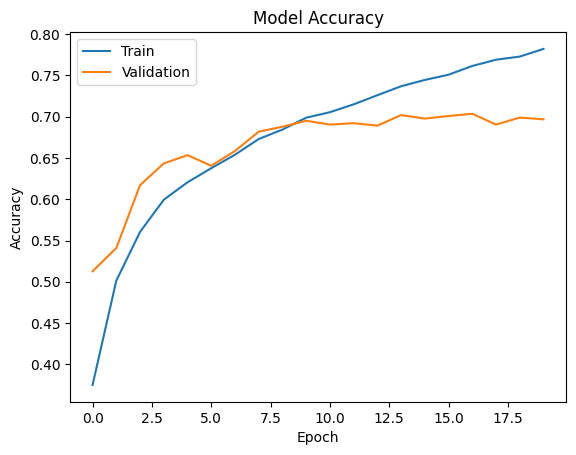

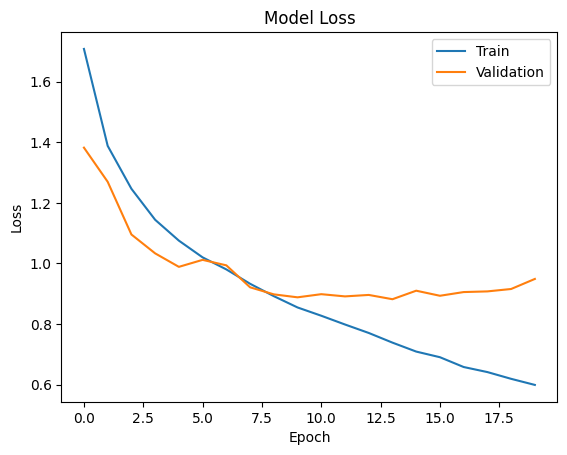

In [17]:
# Visualisasi Akurasi
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Visualisasi Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [18]:
# Evaluasi Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6943 - loss: 0.9492
Test Accuracy: 0.6956999897956848


In [19]:
# Prediksi
import numpy as np
y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [20]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.71      0.75      1000
           1       0.87      0.77      0.81      1000
           2       0.55      0.60      0.57      1000
           3       0.48      0.57      0.52      1000
           4       0.62      0.67      0.64      1000
           5       0.67      0.50      0.57      1000
           6       0.71      0.81      0.76      1000
           7       0.83      0.69      0.76      1000
           8       0.78      0.83      0.81      1000
           9       0.75      0.81      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



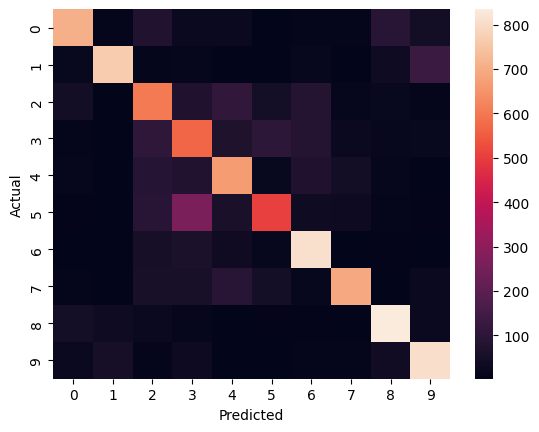

In [21]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()